# 05 · Mid-term candidate representations and features

## Simplified action space

For the mid-term, reduce the representation-selection problem to **five wavelet actions**:

- db4
- db6
- db8
- sym4
- coif3

Everything else is fixed:

- level = 5
- band = 20–800 Hz
- window = 2 s
- fusion = W (wavelet branch only)

This gives **5 executable actions instead of 2,100 full configurations**.

The full wavelet + level + band + window + fusion search is an end-semester extension.


In [1]:
%run ../common/00_config.ipynb
use_half("midsem", oracle="classical")
%run ../common/01_signal_lib.ipynb
%run ../common/02_rl_lib.ipynb

import joblib
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

df = pd.read_csv(P["metadata"] / "records_qc.csv")
df = df[df.qc_keep].reset_index(drop=True)
sig = np.load(P["segments"] / "signals.npz")
fs = CFG["preprocessing"]["fs"]

# Save the original action configuration, then temporarily shrink it.
midterm_wavelets = ["db4", "db6", "db8", "sym4", "coif3"]

CFG["actions"]["wavelet"] = midterm_wavelets
CFG["actions"]["level"] = [5]
CFG["actions"]["band"] = [(20, 800)]
CFG["actions"]["window_s"] = [2.0]
CFG["actions"]["fusion"] = ["W"]

print("Mid-term wavelet actions:", midterm_wavelets)
print("Fixed level:", CFG["actions"]["level"])
print("Fixed band:", CFG["actions"]["band"])
print("Fixed window:", CFG["actions"]["window_s"])
print("Fixed fusion:", CFG["actions"]["fusion"])


Python environment is working
PyTorch: 2.14.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


CirCor version 1.0.3
midsem: results -> results/midsem/ | reward oracle: classical


loaded 01_signal_lib


loaded 02_rl_lib


Mid-term wavelet actions: ['db4', 'db6', 'db8', 'sym4', 'coif3']
Fixed level: [5]
Fixed band: [(20, 800)]
Fixed window: [2.0]
Fixed fusion: ['W']


## Candidate wavelet representations

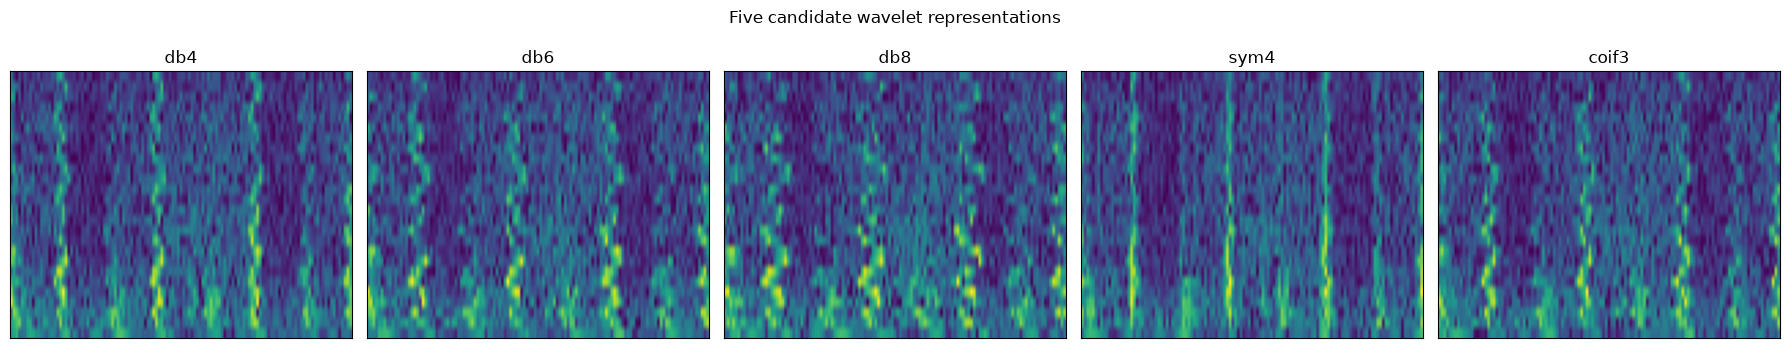

In [2]:
rid = df[df.murmur_label == "Present"].record_id.iloc[0]
x = sig[rid].astype(np.float32)[:2*fs]

fig, ax = plt.subplots(1, 5, figsize=(18, 3.5))
for a, wv in zip(ax, midterm_wavelets):
    M = wavelet_packet_matrix(
        x[:(len(x)//32)*32],
        wv,
        5
    )
    a.imshow(log_compress(M[:26]), origin="lower", aspect="auto")
    a.set_title(wv)
    a.set_xticks([])
    a.set_yticks([])

plt.suptitle("Five candidate wavelet representations")
plt.tight_layout()
savefig(fig, "05_midterm_wavelet_candidates")
plt.show()


## Feature extraction

Only the five wavelet actions are extracted.

No 10 dB noise copy and no 2,100-configuration feature bank is required for the mid-term.


In [3]:
def work(rid, x):
    x = x.astype(np.float32)
    return recording_features(x, CFG)

t0 = time.time()
res = Parallel(n_jobs=-2, batch_size=4)(
    delayed(work)(r, sig[r]) for r in df.record_id
)
print(f"feature extraction for {len(df)} recordings: {time.time() - t0:.0f}s")

keys = list(res[0].keys())
feats = {
    "record_id": df.record_id.tolist(),
    "clean": {k: np.stack([r[k] for r in res]) for k in keys}
}

joblib.dump(
    {
        "features": feats,
        "wavelets": midterm_wavelets,
        "feature_keys": keys
    },
    P["processed"] / "midterm_wavelet_features.joblib",
    compress=3
)

print("Feature keys:", keys)
print("Number of actions:", len(keys))
for k in keys:
    print("action", k, "shape", feats["clean"][k].shape)


feature extraction for 3163 recordings: 14s


Feature keys: [('T', 2.0), ('S', 0, 2.0), ('W', 'db4', 5, 0, 2.0), ('W', 'db6', 5, 0, 2.0), ('W', 'db8', 5, 0, 2.0), ('W', 'sym4', 5, 0, 2.0), ('W', 'coif3', 5, 0, 2.0)]
Number of actions: 7
action ('T', 2.0) shape (3163, 10)
action ('S', 0, 2.0) shape (3163, 20)
action ('W', 'db4', 5, 0, 2.0) shape (3163, 83)
action ('W', 'db6', 5, 0, 2.0) shape (3163, 83)
action ('W', 'db8', 5, 0, 2.0) shape (3163, 83)
action ('W', 'sym4', 5, 0, 2.0) shape (3163, 83)
action ('W', 'coif3', 5, 0, 2.0) shape (3163, 83)


### Output

`midterm_wavelet_features.joblib` contains the five wavelet feature groups used by the simplified RL pipeline.
